In [1]:
!uv pip install torch torchvision matplotlib scikit-learn tqdm

Using Python 3.12.12 environment at: /usr
Audited 5 packages in 355ms


In [2]:
import os
import torch

import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
os.listdir('/kaggle/input/datasets/pkdarabi/bone-break-classification-image-dataset/Bone Break Classification/Bone Break Classification')

['Avulsion fracture',
 'Spiral Fracture',
 'Impacted fracture',
 'Hairline Fracture',
 'Greenstick fracture',
 'Pathological fracture',
 'Oblique fracture',
 'Fracture Dislocation',
 'Longitudinal fracture',
 'Comminuted fracture']

In [4]:
import os
import shutil

original_dataset = "/kaggle/input/datasets/pkdarabi/bone-break-classification-image-dataset/Bone Break Classification/Bone Break Classification"   # your dataset path
new_dataset = "dataset_fixed"

train_path = os.path.join(new_dataset, "train")
test_path = os.path.join(new_dataset, "test")

os.makedirs(train_path, exist_ok=True)
os.makedirs(test_path, exist_ok=True)

for fracture_class in os.listdir(original_dataset):

    class_path = os.path.join(original_dataset, fracture_class)

    if os.path.isdir(class_path):

        train_src = os.path.join(class_path, "Train")
        test_src = os.path.join(class_path, "Test")

        train_dst = os.path.join(train_path, fracture_class)
        test_dst = os.path.join(test_path, fracture_class)

        os.makedirs(train_dst, exist_ok=True)
        os.makedirs(test_dst, exist_ok=True)

        for file in os.listdir(train_src):
            shutil.copy(os.path.join(train_src, file), train_dst)

        for file in os.listdir(test_src):
            shutil.copy(os.path.join(test_src, file), test_dst)

print("Dataset restructuring completed!")

Dataset restructuring completed!


In [5]:
import os
import shutil
from sklearn.model_selection import train_test_split

# Paths
original_dataset = "/kaggle/input/datasets/pkdarabi/bone-break-classification-image-dataset/Bone Break Classification/Bone Break Classification"
new_dataset = "dataset_fixed"
test_size = 0.2  # 20% for testing, 80% for training

# Create main directories
for split in ['train', 'test']:
    os.makedirs(os.path.join(new_dataset, split), exist_ok=True)

# Process each fracture class
for fracture_class in os.listdir(original_dataset):
    class_path = os.path.join(original_dataset, fracture_class)
    
    if not os.path.isdir(class_path):
        continue

    # 1. Gather ALL images for this class from both existing Train and Test folders
    all_images = []
    for subfolder in ['Train', 'Test']:
        subfolder_path = os.path.join(class_path, subfolder)
        if os.path.exists(subfolder_path):
            files = [os.path.join(subfolder_path, f) for f in os.listdir(subfolder_path) 
                     if os.path.isfile(os.path.join(subfolder_path, f))]
            all_images.extend(files)

    # 2. Shuffle and Split
    # This ensures each class is represented proportionally in both sets
    train_files, test_files = train_test_split(
        all_images, 
        test_size=test_size, 
        random_state=42, # Reproducible shuffle
        shuffle=True
    )

    # 3. Create destination subdirectories
    train_dst_dir = os.path.join(new_dataset, 'train', fracture_class)
    test_dst_dir = os.path.join(new_dataset, 'test', fracture_class)
    os.makedirs(train_dst_dir, exist_ok=True)
    os.makedirs(test_dst_dir, exist_ok=True)

    # 4. Copy the files
    for f in train_files:
        shutil.copy(f, os.path.join(train_dst_dir, os.path.basename(f)))
    for f in test_files:
        shutil.copy(f, os.path.join(test_dst_dir, os.path.basename(f)))

    print(f"Processed {fracture_class}: {len(train_files)} train, {len(test_files)} test.")

print("\nDataset restructuring and redistribution completed!")

Processed Avulsion fracture: 98 train, 25 test.
Processed Spiral Fracture: 68 train, 18 test.
Processed Impacted fracture: 67 train, 17 test.
Processed Hairline Fracture: 88 train, 23 test.
Processed Greenstick fracture: 97 train, 25 test.
Processed Pathological fracture: 107 train, 27 test.
Processed Oblique fracture: 68 train, 17 test.
Processed Fracture Dislocation: 124 train, 32 test.
Processed Longitudinal fracture: 64 train, 16 test.
Processed Comminuted fracture: 118 train, 30 test.

Dataset restructuring and redistribution completed!


In [6]:
train_path = 'dataset_fixed/train'
test_path = 'dataset_fixed/test'

In [7]:
for i in os.listdir(train_path):
    print(i, end=': ')
    print(len(os.listdir(train_path+'/'+i)))

Comminuted fracture: 145
Greenstick fracture: 118
Hairline Fracture: 110
Impacted fracture: 83
Longitudinal fracture: 78
Oblique fracture: 82
Spiral Fracture: 84
Fracture Dislocation: 153
Pathological fracture: 133
Avulsion fracture: 122


In [8]:
import numpy as np
import torch
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Constants
IMG_SIZE = 224
MEAN = (0.485, 0.456, 0.406)
STD  = (0.229, 0.224, 0.225)

class AlbumentationsTransform:
    def __init__(self, transform):
        self.transform = transform

    def __call__(self, img):
        # Convert PIL image (from ImageFolder) to NumPy array
        img = np.array(img)
        # Apply Albumentations
        augmented = self.transform(image=img)
        return augmented['image']

# 1. Complex Training Augmentation Pipeline
train_pipeline = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.Rotate(limit=30, p=0.5),
    A.ShiftScaleRotate(
        shift_limit=0.1,
        scale_limit=0.15,
        rotate_limit=30,
        p=0.6
    ),
    A.OneOf([
        A.GaussNoise(),
        A.GaussianBlur(),
        A.MotionBlur()
    ], p=0.3),
    A.OneOf([
        A.RandomBrightnessContrast(),
        A.CLAHE(),
        A.Equalize()
    ], p=0.4),
    A.CoarseDropout(
        max_holes=6,
        max_height=32,
        max_width=32,
        p=0.3
    ),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2()
])

# 2. Simple Test Pipeline (Validation/Test)
test_pipeline = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2()
])

# --- Final Objects to use in your Dataset ---

transform_train = AlbumentationsTransform(train_pipeline)
transform_test = AlbumentationsTransform(test_pipeline)

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_55/3596186699.py:44: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(


In [9]:
train_dataset = datasets.ImageFolder(train_path, transform=transform_train)
test_dataset = datasets.ImageFolder(test_path, transform=transform_test)

# =========================
# DATALOADERS (FAST)
# =========================

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

num_classes = len(train_dataset.classes)

print("Classes:", train_dataset.classes)

Classes: ['Avulsion fracture', 'Comminuted fracture', 'Fracture Dislocation', 'Greenstick fracture', 'Hairline Fracture', 'Impacted fracture', 'Longitudinal fracture', 'Oblique fracture', 'Pathological fracture', 'Spiral Fracture']


In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [11]:
# =========================
# CNN MODEL
# =========================

class CNN(nn.Module):

    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128,256,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256*14*14,512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512,num_classes)
        )

    def forward(self,x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = CNN(num_classes).to(device)

In [30]:
optimizer = optim.Adam(model.parameters(), lr=0.001) 
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=5)
criterion = nn.CrossEntropyLoss()


In [13]:
from tqdm import tqdm

In [31]:
train_losses = []
test_losses = []

train_accuracies = []
test_accuracies = []

epochs = 20

for epoch in range(epochs):

    # -------------------
    # TRAINING
    # -------------------

    model.train()

    train_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        _, predicted = torch.max(outputs,1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = 100 * correct / total
    train_loss = train_loss / len(train_loader)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)


    # -------------------
    # TESTING
    # -------------------

    model.eval()

    test_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            test_loss += loss.item()

            _, predicted = torch.max(outputs,1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    scheduler.step()
    test_acc = 100 * correct / total
    test_loss = test_loss / len(test_loader)

    test_losses.append(test_loss)
    test_accuracies.append(test_acc)

    print(f"\nEpoch {epoch+1}/{epochs}")
    print(f"Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.2f}%")
    print(f"Test  Loss: {test_loss:.4f}  Test  Acc: {test_acc:.2f}%")

100%|██████████| 35/35 [00:03<00:00, 10.64it/s]



Epoch 1/20
Train Loss: 1.7504  Train Acc: 41.16%
Test  Loss: 0.8285  Test  Acc: 83.09%


100%|██████████| 35/35 [00:03<00:00, 11.00it/s]



Epoch 2/20
Train Loss: 1.6939  Train Acc: 43.23%
Test  Loss: 0.7124  Test  Acc: 87.11%


100%|██████████| 35/35 [00:03<00:00, 10.68it/s]


...


Epoch 18/20
Train Loss: 1.4594  Train Acc: 52.44%
Test  Loss: 0.4183  Test  Acc: 93.70%


100%|██████████| 35/35 [00:03<00:00, 10.67it/s]



Epoch 19/20
Train Loss: 1.4430  Train Acc: 51.90%
Test  Loss: 0.5106  Test  Acc: 93.12%


100%|██████████| 35/35 [00:03<00:00, 10.84it/s]



Epoch 20/20
Train Loss: 1.5032  Train Acc: 49.01%
Test  Loss: 0.5485  Test  Acc: 90.83%


In [32]:
# Actually the Previous model reached the 93.98 accuracy.
# Reverts to the old behavior
model = torch.load('classification_model2.pth', weights_only=False)

In [33]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs,1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print("Test Accuracy:",100*correct/total)

Test Accuracy: 93.98280802292264


# Training Data testing as The Training accuracy Seems down because of the complex Augementation

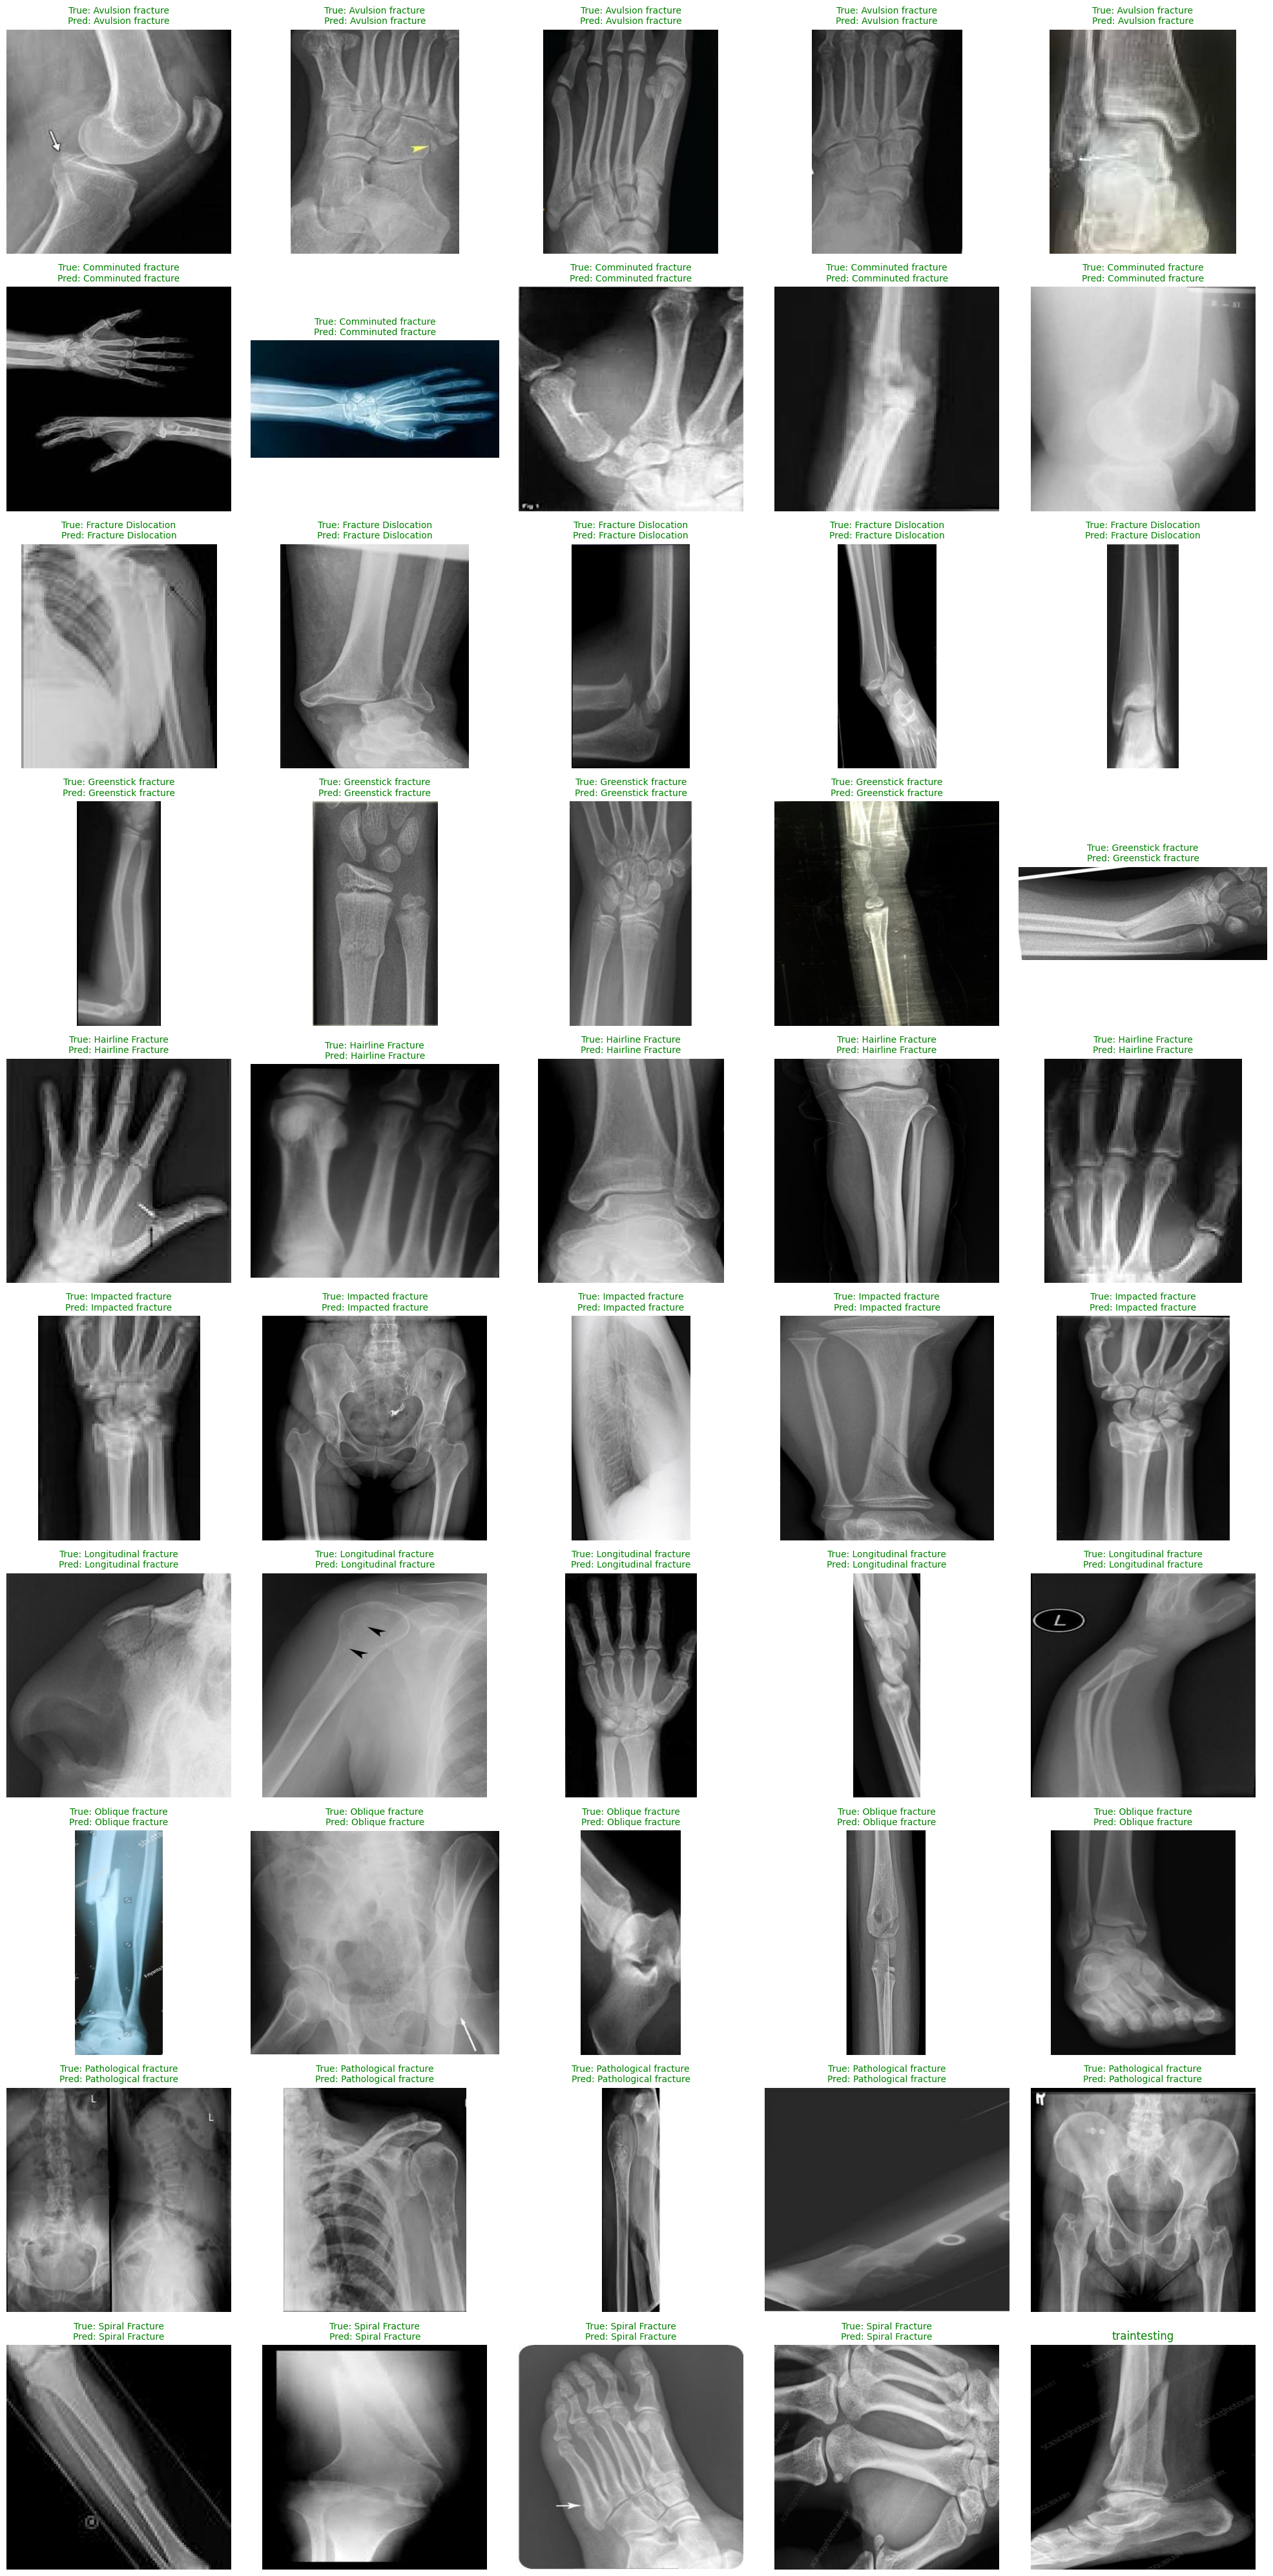

In [36]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import datasets

# 1. Setup paths and model
section = 'train'
test_dir = "dataset_fixed/" + section

# Assuming 'model' is already loaded and in eval mode
model.to(device)
model.eval()

# Get class names from the folder structure
class_names = sorted(os.listdir(test_dir))

# 2. Preparation for visualization
# We'll collect 5 images per class
images_to_show = []
labels_to_show = []
preds_to_show = []

with torch.no_grad():
    for label_idx, class_name in enumerate(class_names):
        class_path = os.path.join(test_dir, class_name)
        if not os.path.isdir(class_path):
            continue
            
        # Get first 5 images in this class
        files = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))][:5]
        
        for file in files:
            img_path = os.path.join(class_path, file)
            raw_image = Image.open(img_path).convert("RGB")
            
            # Apply your transform_test (defined in previous steps)
            # This handles Resize, Normalize, and ToTensorV2
            input_tensor = transform_test(raw_image).unsqueeze(0).to(device)
            
            # Predict
            outputs = model(input_tensor)
            _, predicted = torch.max(outputs, 1)
            
            # Store for plotting
            images_to_show.append(raw_image)
            labels_to_show.append(class_name)
            preds_to_show.append(class_names[predicted.item()])

# 3. Plotting the results
num_classes = len(class_names)
num_images_per_class = 5
fig, axes = plt.subplots(num_classes, num_images_per_class, figsize=(20, 4 * num_classes))

for i in range(len(images_to_show)):
    row = i // num_images_per_class
    col = i % num_images_per_class
    
    ax = axes[row, col]
    ax.imshow(images_to_show[i])
    
    # Green text if correct, Red if wrong
    color = 'green' if labels_to_show[i] == preds_to_show[i] else 'red'
    
    ax.set_title(f"True: {labels_to_show[i]}\nPred: {preds_to_show[i]}", 
                 color=color, fontsize=10)
    ax.axis('off')

plt.title(section + 'testing')
plt.tight_layout()
plt.show()

# Testing Data

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


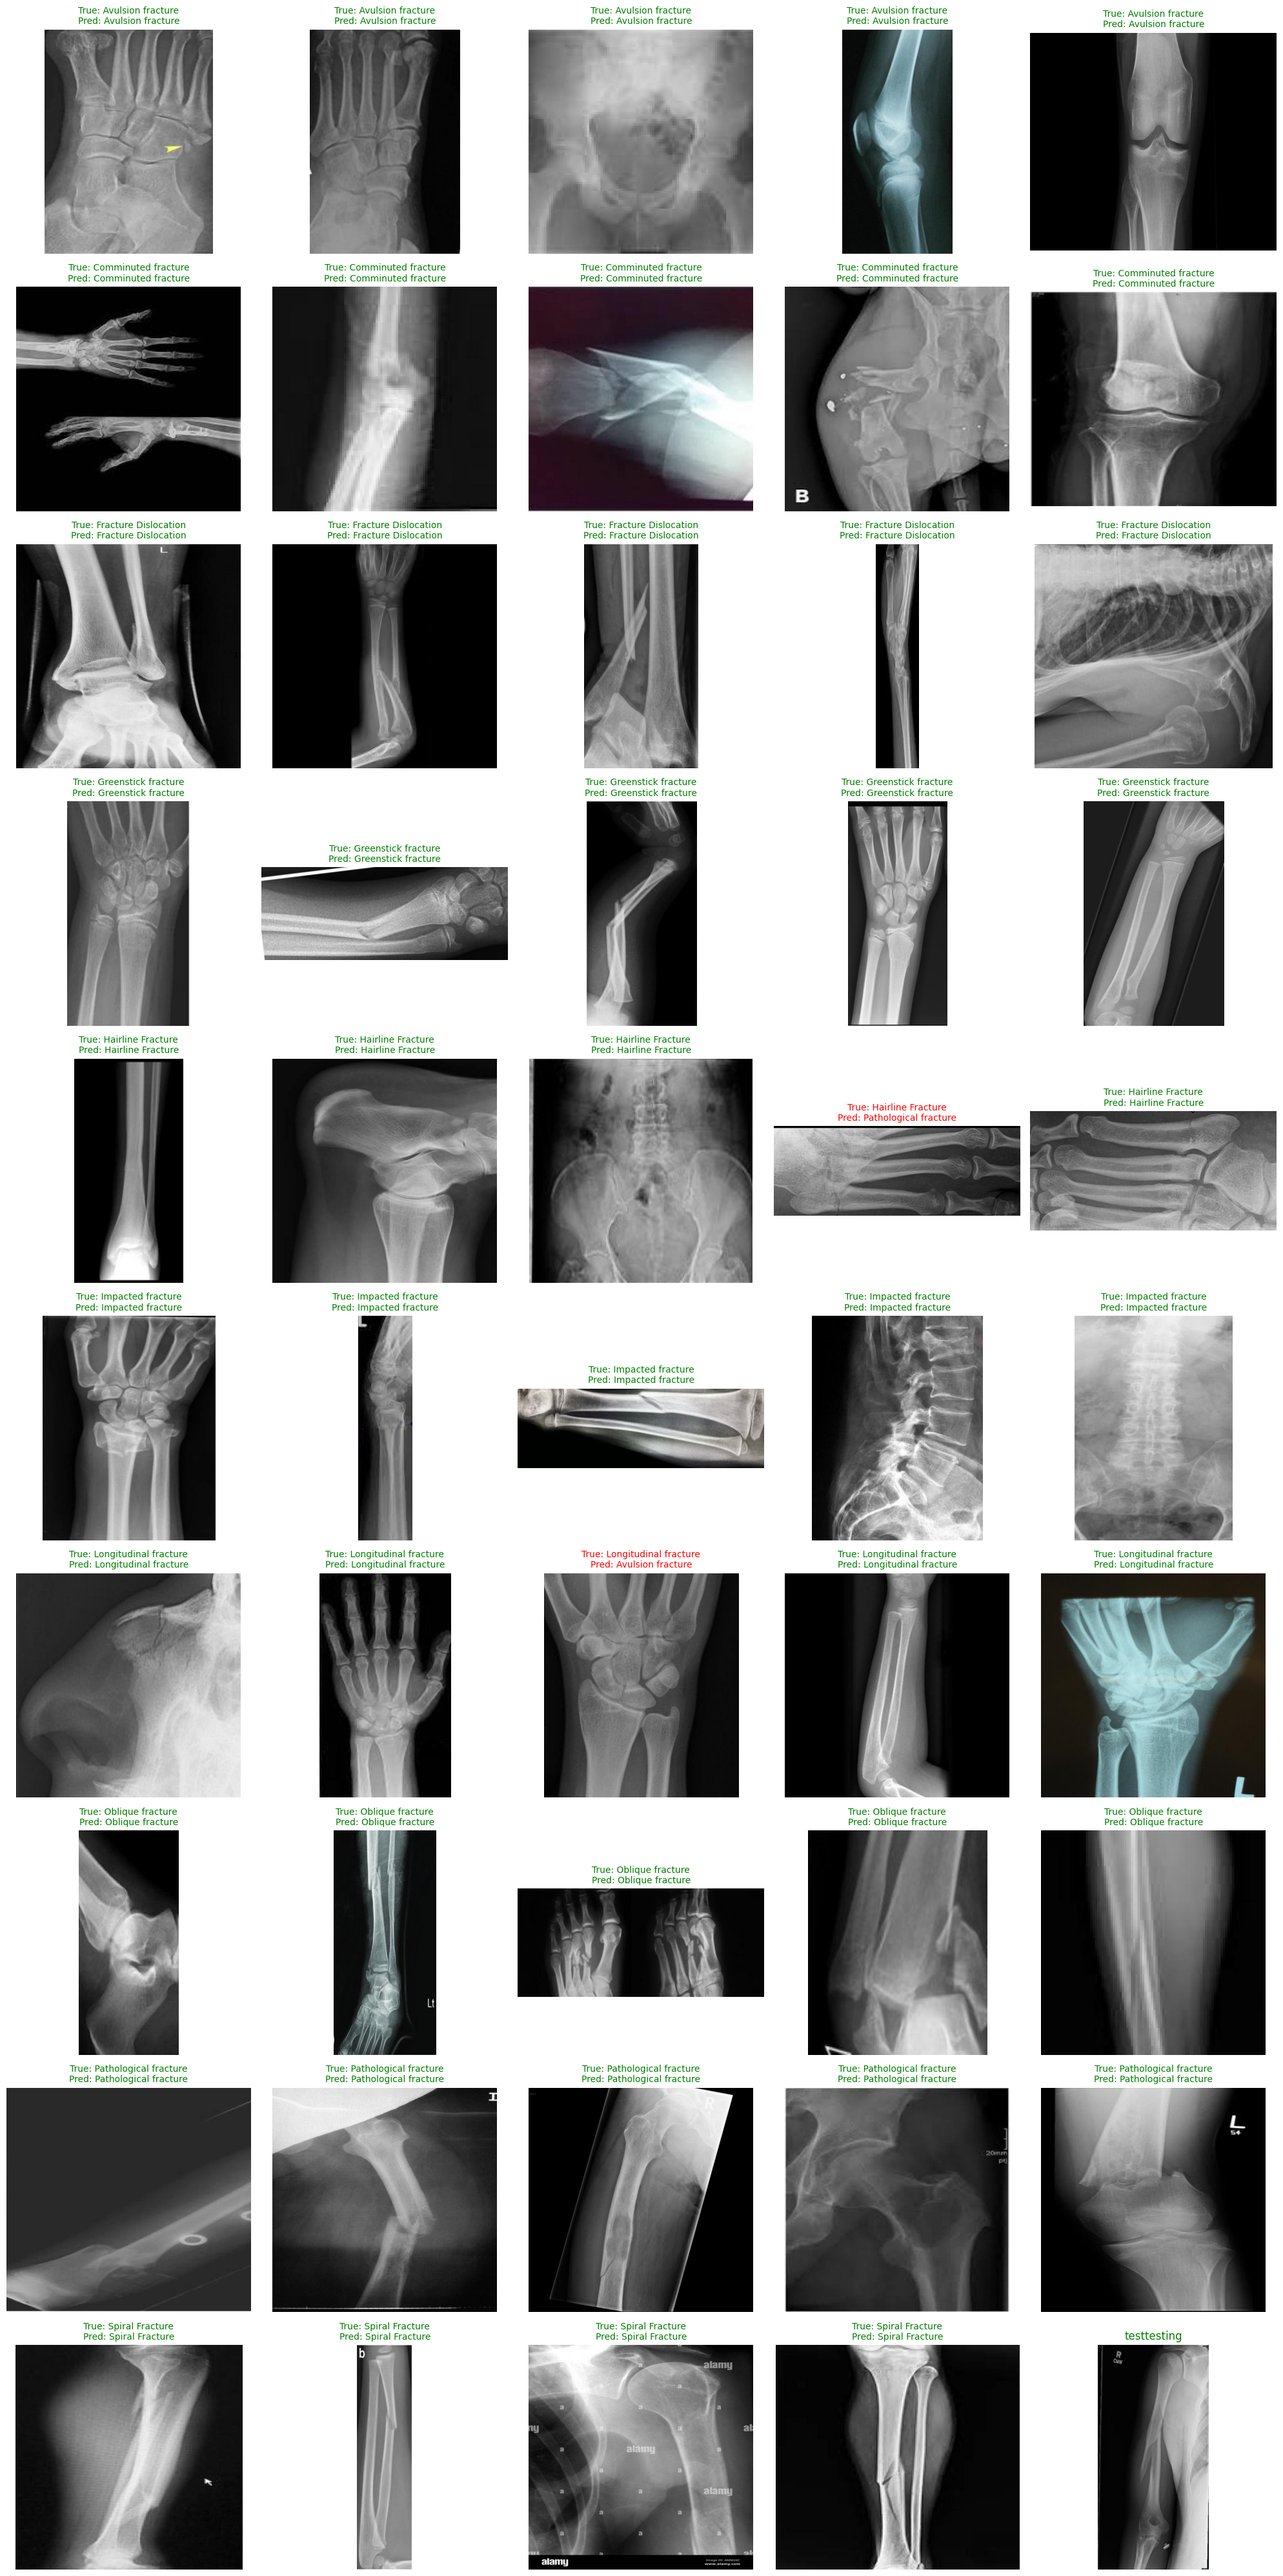

In [38]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import datasets

# 1. Setup paths and model
section = 'test'
test_dir = "dataset_fixed/" + section

# Assuming 'model' is already loaded and in eval mode
model.to(device)
model.eval()

# Get class names from the folder structure
class_names = sorted(os.listdir(test_dir))

# 2. Preparation for visualization
# We'll collect 5 images per class
images_to_show = []
labels_to_show = []
preds_to_show = []

with torch.no_grad():
    for label_idx, class_name in enumerate(class_names):
        class_path = os.path.join(test_dir, class_name)
        if not os.path.isdir(class_path):
            continue
            
        # Get first 5 images in this class
        files = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))][:5]
        
        for file in files:
            img_path = os.path.join(class_path, file)
            raw_image = Image.open(img_path).convert("RGB")
            
            # Apply your transform_test (defined in previous steps)
            # This handles Resize, Normalize, and ToTensorV2
            input_tensor = transform_test(raw_image).unsqueeze(0).to(device)
            
            # Predict
            outputs = model(input_tensor)
            _, predicted = torch.max(outputs, 1)
            
            # Store for plotting
            images_to_show.append(raw_image)
            labels_to_show.append(class_name)
            preds_to_show.append(class_names[predicted.item()])

# 3. Plotting the results
num_classes = len(class_names)
num_images_per_class = 5
fig, axes = plt.subplots(num_classes, num_images_per_class, figsize=(20, 4 * num_classes))

for i in range(len(images_to_show)):
    row = i // num_images_per_class
    col = i % num_images_per_class
    
    ax = axes[row, col]
    ax.imshow(images_to_show[i])
    
    # Green text if correct, Red if wrong
    color = 'green' if labels_to_show[i] == preds_to_show[i] else 'red'
    
    ax.set_title(f"True: {labels_to_show[i]}\nPred: {preds_to_show[i]}", 
                 color=color, fontsize=10)
    ax.axis('off')

plt.title(section + 'testing')
plt.tight_layout()
plt.show()

# Fine Tuning 

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

model = models.efficientnet_b3(weights="IMAGENET1K_V1")

In [ ]:
for param in model.parameters():
    param.requires_grad = False

In [ ]:
for param in model.features[-1:].parameters():
    param.requires_grad = True

In [ ]:
num_features = model.classifier[1].in_features

model.classifier = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(num_features, num_classes)
)

In [ ]:
model = model.to(device)

In [ ]:
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5
)
criterion = nn.CrossEntropyLoss()

In [ ]:
train_losses = []
test_losses = []

train_accuracies = []
test_accuracies = []

epochs = 50

for epoch in range(epochs):

    # -------------------
    # TRAINING
    # -------------------

    model.train()

    train_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        _, predicted = torch.max(outputs,1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = 100 * correct / total
    train_loss = train_loss / len(train_loader)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)


    # -------------------
    # TESTING
    # -------------------

    model.eval()

    test_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            test_loss += loss.item()

            _, predicted = torch.max(outputs,1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    scheduler.step()
    test_acc = 100 * correct / total
    test_loss = test_loss / len(test_loader)

    test_losses.append(test_loss)
    test_accuracies.append(test_acc)

    print(f"\nEpoch {epoch+1}/{epochs}")
    print(f"Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.2f}%")
    print(f"Test  Loss: {test_loss:.4f}  Test  Acc: {test_acc:.2f}%")